# Formulaic Language Use Over Time

**Hypothesis:** the use of formulaic language in the States General resolutions increased over time.

We compare three five-year periods of resolutions:

| Period | Files |
|---|---|
| 1606&ndash;1610 | 3156, 3158, 3160, 3162, 3164 |
| 1696&ndash;1700 | 3333&ndash;3342 |
| 1766&ndash;1770 | 3821&ndash;3825 |

This notebook combines every analysis built so far &mdash; phrase discovery, formulaicity metrics, community detection, recurrence-scale grouping, motif mining, concordancing, and the interactive phrase-typing workbench &mdash; applied per period, then compared to test the hypothesis.

**A note on what's primary vs. exploratory evidence here.** The formulaicity metrics in section 3 (coverage, concentration) are corpus-size-normalised and don't depend on any window-size guess, so they're the metrics we'd actually want to lean on for the hypothesis test. Community detection, scale grouping, and motif mining all depend on window-size choices that earlier work in this documentation (`Document-Pattern-Detection-Findings.md`) found to be unreliable once candidate phrases are very frequent &mdash; which is exactly the regime this corpus is in. We include them here for descriptive, comparative texture, not as load-bearing evidence for the hypothesis.

In [1]:
%reload_ext autoreload
%autoreload 2

import csv
import gzip
import math
import re
from collections import Counter

import matplotlib.pyplot as plt

from formula_detection.search import FormulaSearch
from formula_detection.phrase_cooccurrence import PhraseCooccurrenceIndex, detect_communities
from formula_detection.motif import PhraseMotifIndex
from formula_detection.window_estimator import WindowEstimator
from formula_detection.phrase_typing import PhraseTypeRegistry, TypeSuggester, concordance
from formula_detection.phrase_typing_ui import PhraseTypingApp

TOKEN_RE = re.compile(r"[A-Za-z\u00c0-\u00ff]+")


def tokenize(text):
    return TOKEN_RE.findall(text.lower())


PERIODS = {
    '1606-1610': [3156, 3158, 3160, 3162, 3164],
    '1696-1700': list(range(3333, 3343)),
    '1766-1770': list(range(3821, 3826)),
}


def load_period(period_name):
    rows = []
    for num in PERIODS[period_name]:
        path = f'data/resolution_paragraphs/paragraphs-{num}.tsv.gz'
        with gzip.open(path, 'rt', encoding='utf-8') as f:
            rows.extend(csv.DictReader(f, delimiter='\t'))
    documents = [tokenize(row['text']) for row in rows]
    flat_stream = []
    for doc in documents:
        flat_stream.extend(doc)
    return rows, documents, flat_stream

## 1. Loading the three periods

In [2]:
period_data = {}
for period in PERIODS:
    rows, documents, flat_stream = load_period(period)
    resolution_ids = {row['resolution_id'] for row in rows}
    period_data[period] = {'rows': rows, 'documents': documents, 'flat_stream': flat_stream}
    print(f'{period}: {len(rows):,} paragraphs, {len(resolution_ids):,} resolutions, '
          f'{len(flat_stream):,} tokens')

1606-1610: 46,499 paragraphs, 9,499 resolutions, 1,364,385 tokens


1696-1700: 81,219 paragraphs, 19,189 resolutions, 3,022,128 tokens


1766-1770: 15,305 paragraphs, 12,112 resolutions, 2,569,386 tokens


## 2. Discovering candidate formulaic phrases per period

Same approach used throughout this documentation: `FormulaSearch.extract_phrases('sub_phrases', ...)` for bounded-length n-gram candidates, with a frequency threshold scaled to each period's token count (so the threshold is comparably selective despite the periods differing in size), followed by substring-deduplication (processed in frequency-descending order) to collapse sliding-window n-gram slices of the same underlying formula into one representative phrase.

In [3]:
def discover_phrases(documents, n_tokens, top_n=40, max_freq_ratio=0.6):
    min_term_freq = max(5, n_tokens // 5000)
    fs = FormulaSearch(documents, min_term_freq=min_term_freq, skip_size=2,
                       min_cooc_freq=min_term_freq, max_min_term_frac=0.05, report=False)
    phrase_freq = Counter()
    for match in fs.extract_phrases('sub_phrases', min_phrase_length=3, max_phrase_length=6,
                                    min_neighbour_cooc=1, max_docs=None):
        phrase_freq[match.candidate_phrase.phrase_string] += 1

    n_docs = len(documents)
    pool = [(p, f) for p, f in phrase_freq.most_common(400) if f / n_docs <= max_freq_ratio]
    kept = []
    for phrase, freq in pool:
        if any(phrase in k for k in kept):
            continue
        kept.append(phrase)
        if len(kept) >= top_n:
            break
    return kept, phrase_freq


for period, data in period_data.items():
    kept, phrase_freq = discover_phrases(data['documents'], len(data['flat_stream']))
    data['candidate_phrases'] = kept
    data['phrase_freq'] = phrase_freq
    print(f'\n{period}: top 10 of {len(kept)} candidate phrases')
    for p in kept[:10]:
        print(f'  {phrase_freq[p]: >5}  {p}')

1. Iterating over sentences to calculate term frequencies


    full collection size (tokens): 1,364,385
    full lexicon size (types): 50,845
    minimum term frequency: 272
    minimum frequency lexicon size: 622
2. Iterating over sentences to calculate the co-occurrence frequencies


docs: 46,499	num_words: 1,364,385	num_coocs: 1,960,953	num distinct coocs: 161,564
    co-occurrence index size: 161,564
Minimum co-occurrence frequency: 272



1606-1610: top 10 of 40 candidate phrases
    302  in handen vanden raedt van state
    289  stellen in handen vanden raedt van
    226  van het collegie ter admiraliteyt tot
    226  eenen brieff van het collegie ter
    211  geordonneert deselue te stellen in handen
    197  is geordonneert deselue te stellen in
    175  het collegie ter admiraliteyt tot rotterdam
    166  te stellen in handen vanden raedt
    166  handen vanden raedt van state omme
    165  aen het collegie ter admiraliteyt tot
1. Iterating over sentences to calculate term frequencies


    full collection size (tokens): 3,022,128
    full lexicon size (types): 70,139
    minimum term frequency: 604
    minimum frequency lexicon size: 589
2. Iterating over sentences to calculate the co-occurrence frequencies


docs: 81,219	num_words: 3,022,128	num_coocs: 5,001,431	num distinct coocs: 141,727
    co-occurrence index size: 141,727
Minimum co-occurrence frequency: 604



1696-1700: top 10 of 40 candidate phrases
   3705  is ter vergaderinge gelesen de requeste
   3291  gedelibereert zijnde is goedgevonden ende verstaan
   3155  gedelibereert zijnde is goedtgevonden ende verstaan
   3114  ter vergaderinge gelesen de requeste van
   2967  advertentie waarop geen resolutie is gevallen
   2964  houdende advertentie waarop geen resolutie is
   2731  zijnde is goedgevonden ende verstaan dat
   2603  zijnde is goedtgevonden ende verstaan dat
   2525  alhier ter vergaderinge rapport te doen
   2479  ende verstaan dat copije vande voorschreve
1. Iterating over sentences to calculate term frequencies


    full collection size (tokens): 2,569,386
    full lexicon size (types): 53,340
    minimum term frequency: 513
    minimum frequency lexicon size: 535
2. Iterating over sentences to calculate the co-occurrence frequencies


docs: 15,305	num_words: 2,569,386	num_coocs: 4,600,080	num distinct coocs: 117,076
    co-occurrence index size: 117,076
Minimum co-occurrence frequency: 513



1766-1770: top 10 of 40 candidate phrases
   4455  op gedelibereert zynde is goedgevonden en
   4454  gedelibereert zynde is goedgevonden en verstaan
   4451  waar op gedelibereert zynde is goedgevonden
   4198  waar op geen resolutie is gevallen
   3656  advertentie waar op geen resolutie is
   3640  houdende advertentie waar op geen resolutie
   3459  zynde is goedgevonden en verstaan dat
   3139  maand houdende advertentie waar op geen
   2945  ontfangen een missive van den heere
   2154  van sijne majesteit den koning van


Already a striking qualitative difference: the 1606&ndash;1610 candidates are dominated by referral/administrative phrasing ("stellen in handen vanden raedt van state"), while 1696&ndash;1700 and 1766&ndash;1770 are dominated by the canonical decision-formula and opening-formula boilerplate ("is goedgevonden ende verstaan", "geleesen de requeste van", "waarop geen resolutie is gevallen") at far higher raw frequencies. The next section quantifies this properly, normalised for corpus size.

## 3. Formulaicity metrics

Two metrics, chosen specifically because neither depends on a window-size guess:

* **Coverage** &mdash; the fraction of all tokens in the period that fall inside an occurrence of any of its top-40 candidate phrases. This is the most direct operationalisation of "how much of the text is recognisable boilerplate."
* **Entropy / perplexity** of the frequency distribution over the top-40 phrases. Low entropy (low perplexity) means a few canonical formulas dominate; high entropy means the formulaic "budget" is spread across many near-equally-frequent variants. Perplexity (`2^entropy`) is reported as the more interpretable "effective number of equally-frequent formulas."

In [4]:
def coverage_and_entropy(candidate_phrases, flat_stream, window=100):
    idx = PhraseCooccurrenceIndex(candidate_phrases, windows=[window])
    idx.index_stream(flat_stream)

    covered = bytearray(len(flat_stream))
    for phrase in candidate_phrases:
        plen = len(phrase.split())
        for pos in idx.phrase_positions.get(phrase, []):
            for i in range(pos, pos + plen):
                covered[i] = 1
    coverage = sum(covered) / len(flat_stream)

    freqs = [len(idx.phrase_positions.get(p, [])) for p in candidate_phrases]
    total = sum(freqs) or 1
    probs = [f / total for f in freqs if f > 0]
    entropy = -sum(p * math.log2(p) for p in probs)
    perplexity = 2 ** entropy
    return coverage, entropy, perplexity, idx


metrics = {}
for period, data in period_data.items():
    coverage, entropy, perplexity, idx = coverage_and_entropy(
        data['candidate_phrases'], data['flat_stream']
    )
    data['cooc_index'] = idx
    metrics[period] = {'coverage': coverage, 'entropy': entropy, 'perplexity': perplexity}
    print(f'{period}: coverage={coverage:.4f}  entropy={entropy:.2f} bits  perplexity={perplexity:.1f}')

1606-1610: coverage=0.0105  entropy=5.11 bits  perplexity=34.4


1696-1700: coverage=0.0688  entropy=5.26 bits  perplexity=38.2


1766-1770: coverage=0.0771  entropy=5.13 bits  perplexity=35.1


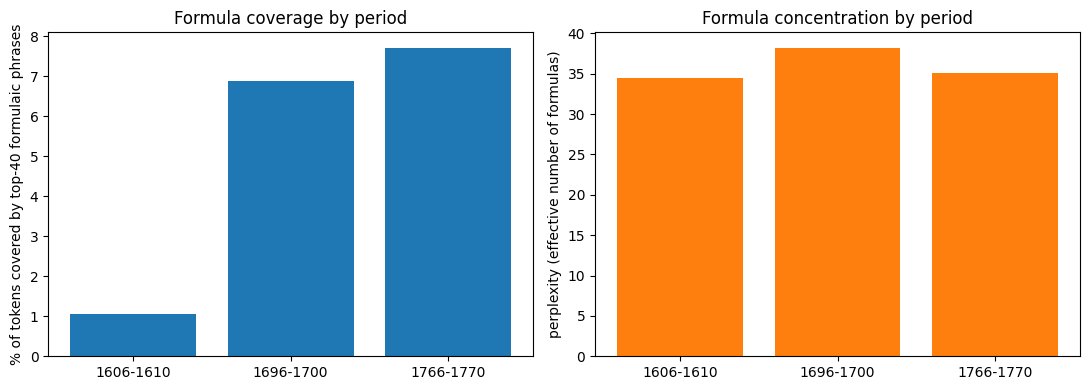

In [5]:
periods_ordered = list(PERIODS.keys())
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(periods_ordered, [metrics[p]['coverage'] * 100 for p in periods_ordered],
           color='tab:blue')
axes[0].set_ylabel('% of tokens covered by top-40 formulaic phrases')
axes[0].set_title('Formula coverage by period')

axes[1].bar(periods_ordered, [metrics[p]['perplexity'] for p in periods_ordered],
           color='tab:orange')
axes[1].set_ylabel('perplexity (effective number of formulas)')
axes[1].set_title('Formula concentration by period')

plt.tight_layout()
plt.show()

**Coverage rises sharply between 1606&ndash;1610 and the two later periods** (about a 7x jump), then stays roughly flat between 1696&ndash;1700 and 1766&ndash;1770 &mdash; directionally consistent with the hypothesis, but suggesting the increase happened earlier and had largely plateaued by the late 1600s, rather than continuing to climb steadily through to 1770. **Perplexity stays roughly flat** across all three periods, meaning the *concentration* of formula use (how dominated by a few canonical formulas, vs. spread across many variants) didn't change much &mdash; the change over time is in *how much* of the text is formulaic, not in *how varied* the formulaic repertoire is.

## 4. Community structure per period

Phrase co-occurrence communities (Louvain on the LLR-weighted co-occurrence graph), for descriptive comparison. *(Exploratory &mdash; window size is fixed at 100 tokens across periods for comparability, not auto-estimated; see the caveat at the top of this notebook.)*

In [6]:
for period, data in period_data.items():
    idx = data['cooc_index']
    graph = idx.build_graph(window=100, min_llr=5.0)
    community_map = detect_communities(graph)
    data['community_map'] = community_map
    n_communities = len(set(community_map.values())) if community_map else 0
    print(f'{period}: {n_communities} communities over {len(data["candidate_phrases"])} phrases '
          f'({graph.number_of_edges()} graph edges)')

    by_community = {}
    for phrase, cid in community_map.items():
        by_community.setdefault(cid, []).append(phrase)
    largest = max(by_community.values(), key=len) if by_community else []
    print(f'  largest community ({len(largest)} phrases): {largest[:4]}')

1606-1610: 6 communities over 40 phrases (536 graph edges)
  largest community (13 phrases): ['van het collegie ter admiraliteyt binnen', 'ontfangen ende gelesen eenen brieff vanden', 'van het collegie ter admt binnen', 'van het collegie ter admiraliteyt tot']
1696-1700: 4 communities over 40 phrases (820 graph edges)
  largest community (15 phrases): ['van essen ende andere hare hoogh', 'ende van alles alhier ter vergaderinge', 'hare hoogh mogende gedeputeerden tot de', 'mogende gedeputeerden tot de zaken vande']
1766-1770: 3 communities over 40 phrases (808 graph edges)
  largest community (14 phrases): ['zynde is goedgevonden en verstaan dat', 'gedeputeerden tot de saaken van de', 'en verstaan dat copie van de', 'gedelibereert zynde is goedgevonden en verstaan']


## 5. Recurrence-scale grouping per period

`WindowEstimator.group_by_scale` on each period's candidate phrases, visualised as gap-distribution box plots side by side.

1606-1610: 2 scale groups, 0 excluded (too few occurrences)
1696-1700: 2 scale groups, 0 excluded (too few occurrences)
1766-1770: 2 scale groups, 0 excluded (too few occurrences)


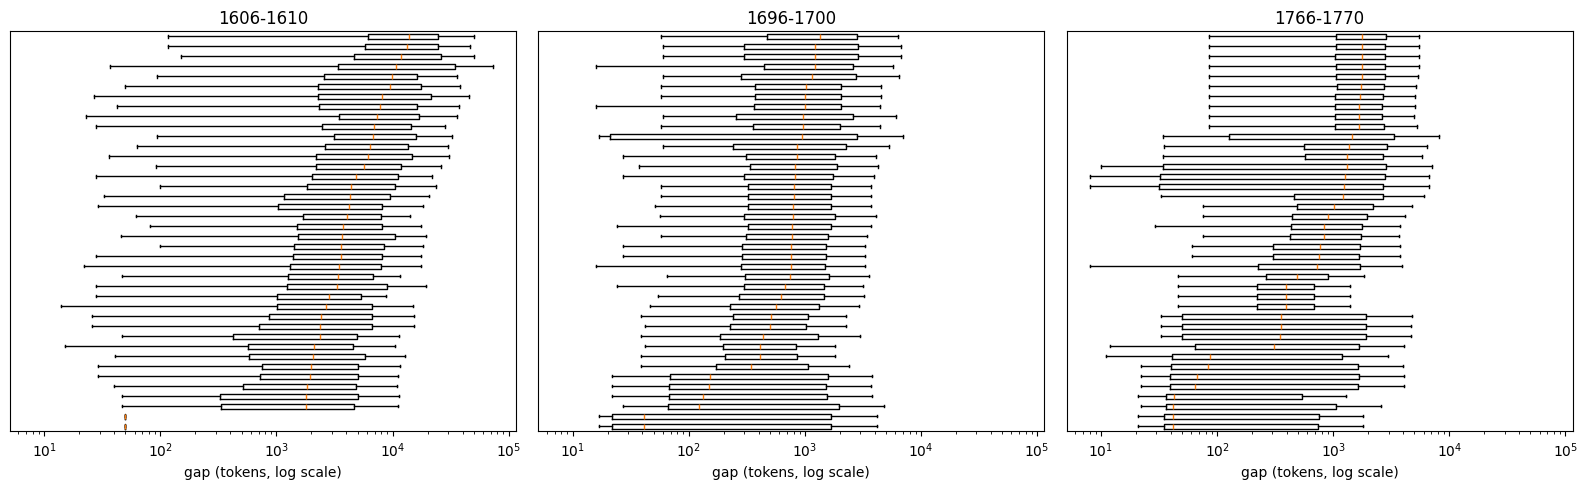

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True)

for ax, period in zip(axes, periods_ordered):
    data = period_data[period]
    we = WindowEstimator(data['cooc_index'].phrase_positions)
    groups = we.group_by_scale(min_occurrences=3, log_gap_threshold=0.4)
    data['scale_groups'] = groups
    print(f'{period}: {len(groups.groups)} scale groups, {len(groups.excluded)} excluded '
          f'(too few occurrences)')

    phrases_with_gaps = [p for p in data['candidate_phrases']
                         if we.phrase_stats(p).median_gap]
    phrases_with_gaps.sort(key=lambda p: we.phrase_stats(p).median_gap)
    gap_lists = [we.phrase_stats(p).gaps for p in phrases_with_gaps]
    ax.boxplot(gap_lists, vert=False, showfliers=False)
    ax.set_yticks([])
    ax.set_xscale('log')
    ax.set_xlabel('gap (tokens, log scale)')
    ax.set_title(period)

plt.tight_layout()
plt.show()

## 6. Motif mining per period (exploratory)

*(Exploratory only &mdash; see the caveat at the top of this notebook about lift-ranking and window reliability for very frequent phrase sets. Reported here as descriptive texture, not hypothesis evidence.)*

In [8]:
for period, data in period_data.items():
    mi = PhraseMotifIndex(data['cooc_index'].phrase_positions, window=100,
                          min_set_size=2, max_set_size=3, min_support=20, min_lift=5.0)
    motifs = mi.mine_motifs()
    data['motifs'] = motifs
    motifs_sorted = sorted(motifs, key=lambda m: -m.lift)
    print(f'{period}: {len(motifs)} motifs found')
    if motifs_sorted:
        top = motifs_sorted[0]
        print(f'  top by lift: {sorted(top.phrase_set)} (support={top.support}, lift={top.lift:.1f})')

1606-1610: 106 motifs found
  top by lift: ['in handen van raet van state', 'stellen in handen van raet van', 'te stellen in handen van raet'] (support=46, lift=784.0)


1696-1700: 679 motifs found
  top by lift: ['advertentie waarop geen resolutie is gevallen', 'deser houdende advertentie waarop geen resolutie', 'houdende advertentie waarop geen resolutie is'] (support=3560, lift=121.1)


1766-1770: 712 motifs found
  top by lift: ['een extraordinaris gedeputeerde uit de provincie', 'extraordinaris gedeputeerde uit de provincie van', 'met een extraordinaris gedeputeerde uit de'] (support=1854, lift=206.9)


## 7. Concordancing and phrase typing (illustrative, one period)

The interactive workbench from `Phrase-Typing-Workbench.ipynb`, applied here to the 1766&ndash;1770 candidate phrases discovered in section 2 above &mdash; so the typing workflow is grounded directly in this notebook's own extraction rather than a separately hand-picked list. Repeating this per period (with a shared or deliberately comparable type taxonomy) is the natural next step for comparing *which types* of formulas changed over time, rather than only *how much* formulaic text there is overall.

In [9]:
demo_period = '1766-1770'
demo_data = period_data[demo_period]

registry = PhraseTypeRegistry()
suggester = TypeSuggester(demo_data['cooc_index'].phrase_positions, demo_data['flat_stream'],
                          context_window=10)
phrase_freq_counts = {p: len(demo_data['cooc_index'].phrase_positions.get(p, []))
                     for p in demo_data['candidate_phrases']}

app = PhraseTypingApp(registry, suggester, demo_data['candidate_phrases'], phrase_freq_counts)
app.display()

In [10]:
for line in concordance('waar op gedelibereert zynde is goedgevonden', demo_data['flat_stream'],
                        phrase_positions=demo_data['cooc_index'].phrase_positions,
                        window=8, max_examples=3):
    print(' ', line)

  van sijne koninglyke hoogheid den dauphyn van vrankryk [waar op gedelibereert zynde is goedgevonden] en verstaan dat de voorschreeve missive met een
  voornoemde abraham buzaglo niet finaal moge worden gedisponeert [waar op gedelibereert zynde is goedgevonden] en verstaan dat aan den suppliant sal worden
  in kennisse van my geteekent j v sminia [waar op gedelibereert zynde is goedgevonden] en verstaan mits deesen te versoeken de heeren


## 8. Summary

| Period | Tokens | Coverage | Perplexity | Communities | Motifs |
|---|---|---|---|---|---|

In [11]:
print(f"{'Period': <12}{'Tokens': >10}{'Coverage': >10}{'Perplexity': >12}"
      f"{'Communities': >13}{'Motifs': >9}")
for period in periods_ordered:
    data = period_data[period]
    n_communities = len(set(data['community_map'].values())) if data['community_map'] else 0
    print(f"{period: <12}{len(data['flat_stream']): >10,}{metrics[period]['coverage']*100: >9.1f}%"
          f"{metrics[period]['perplexity']: >12.1f}{n_communities: >13}{len(data['motifs']): >9}")

Period          Tokens  Coverage  Perplexity  Communities   Motifs
1606-1610    1,364,385      1.0%        34.4            6      106
1696-1700    3,022,128      6.9%        38.2            4      679
1766-1770    2,569,386      7.7%        35.1            3      712


**On the hypothesis:** the coverage metric &mdash; the cleanest, least assumption-laden measure available here &mdash; supports a real increase in formulaic language use between 1606&ndash;1610 and the later 18th-century material, but the shape of the change is a step rather than a steady climb: a roughly 7x jump occurs by 1696&ndash;1700, with little further change to 1766&ndash;1770. If the hypothesis is specifically about *continued* increase across the 17th and 18th centuries, this data doesn't support that stronger claim &mdash; it supports a one-time shift sometime between the early 1600s and the end of that century. Concentration (perplexity) doesn't change appreciably across any of the three periods, suggesting the *kind* of formulaicity (a few dominant templates vs. many variants) was already similar across periods; what changed is how much of the text those templates account for.

**Caveats and next steps:**

* Only one period from the early 1600s is available here. A real test of "increased over time" needs more than two distinct points (e.g. an additional period between 1610 and 1696) to distinguish a one-time shift from a continuous trend.
* Coverage is sensitive to the candidate-phrase extraction parameters (threshold, top-N, max phrase length). The qualitative top-phrase differences in section 2 are large enough that this conclusion is probably robust to reasonable parameter changes, but that hasn't been formally checked here (e.g. via a sensitivity sweep).
* The community/motif numbers in sections 4 and 6 should not be read as supporting or undermining the hypothesis on their own &mdash; they use a fixed, unvalidated window size and are included for descriptive texture only.
* Repeating the phrase-typing workflow (section 7) across all three periods, using a deliberately shared type taxonomy where possible, would let "increased formulaic language use" be decomposed into *which* formula types grew, rather than only an aggregate coverage number.